# Análisis comparativo — Conti · Black Basta · LockBit · Exploit.in

Compara el estilo semántico de los actores de los 4 grupos usando  
los embeddings generados en los módulos 03 de cada uno.

**Fundamento**: todos los datasets se embebieron con `qwen3-embedding` →  
los vectores viven en el **mismo espacio de 4096 dimensiones** →  
la similitud coseno entre actores de distintos grupos es matemáticamente comparable.

| Grupo | Tipo de dato | Periodo | Actores |
|---|---|---|---|
| Conti | Chats internos filtrados | 2020–2022 | 30 |
| Black Basta | Chats internos filtrados | 2023–2024 | 47 |
| LockBit | Panel de negociación (operadores) | dic 2024–abr 2025 | 20 |
| Exploit.in | Foro underground ruso | 2005–2008 | 156 |

Requiere haber ejecutado los notebooks `03_embeddings` de cada módulo.

## 0. Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import umap
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

BASE = Path('..')

# --- Paths ---
CONTI_EMB      = BASE / 'ContiLeaks/data/processed/message_embeddings.npy'
CONTI_SAMPLE   = BASE / 'ContiLeaks/data/processed/conti_sample_with_embeddings.parquet'
CONTI_PROFILES = BASE / 'ContiLeaks/data/processed/actor_profiles.json'

BB_EMB         = BASE / 'BlackBasta/data/processed/bb_message_embeddings.npy'
BB_SAMPLE      = BASE / 'BlackBasta/data/processed/bb_sample_with_embeddings.parquet'
BB_PROFILES    = BASE / 'BlackBasta/data/processed/bb_actor_profiles.json'

LK_EMB         = BASE / 'LockBit/data/processed/chat_embeddings.npy'
LK_SAMPLE      = BASE / 'LockBit/data/processed/chats_with_embeddings.parquet'
LK_PROFILES    = BASE / 'LockBit/data/processed/operator_profiles.json'
LK_USERS       = BASE / 'LockBit/data/processed/users.parquet'

EI_EMB         = BASE / 'ExploitIn/data/processed/exploitin_message_embeddings.npy'
EI_SAMPLE      = BASE / 'ExploitIn/data/processed/exploitin_sample_with_embeddings.parquet'
EI_PROFILES    = BASE / 'ExploitIn/data/processed/exploitin_user_profiles.json'

for p in [CONTI_EMB, CONTI_SAMPLE, CONTI_PROFILES,
           BB_EMB, BB_SAMPLE, BB_PROFILES,
           LK_EMB, LK_SAMPLE, LK_PROFILES, LK_USERS,
           EI_EMB, EI_SAMPLE, EI_PROFILES]:
    assert p.exists(), f'Falta: {p}'

# --- Cargar embeddings ---
conti_emb = np.load(CONTI_EMB)
bb_emb    = np.load(BB_EMB)
lk_emb    = np.load(LK_EMB)
ei_emb    = np.load(EI_EMB)

# --- Cargar parquets ---
conti_msgs = pd.read_parquet(CONTI_SAMPLE).reset_index(drop=True)
bb_msgs    = pd.read_parquet(BB_SAMPLE).reset_index(drop=True)
lk_msgs    = pd.read_parquet(LK_SAMPLE).reset_index(drop=True)
ei_msgs    = pd.read_parquet(EI_SAMPLE).reset_index(drop=True)
lk_users   = pd.read_parquet(LK_USERS)

# --- Cargar perfiles ---
with open(CONTI_PROFILES)  as f: conti_profiles = json.load(f)
with open(BB_PROFILES)     as f: bb_profiles    = json.load(f)
with open(LK_PROFILES)     as f: lk_profiles    = json.load(f)
with open(EI_PROFILES)     as f: ei_profiles    = json.load(f)

# Mapa advid → login para LockBit
advid_to_login = dict(zip(lk_users['id'], lk_users['login']))

print(f'Conti    : {conti_emb.shape}  — {conti_msgs.username.nunique()} actores')
print(f'BlackBasta: {bb_emb.shape}  — {bb_msgs.username.nunique()} actores')
print(f'LockBit  : {lk_emb.shape}  — {lk_msgs[lk_msgs.flag==1].advid.nunique()} operadores')
print(f'ExploitIn: {ei_emb.shape}  — {ei_msgs.username.nunique()} autores ({len(ei_profiles)} perfilados)')
print(f'\nEspacio vectorial compartido: {conti_emb.shape[1]}D  ✅')

/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Conti    : (1500, 4096)  — 30 actores
BlackBasta: (3598, 4096)  — 47 actores
LockBit  : (3977, 4096)  — 29 operadores
ExploitIn: (5289, 4096)  — 1081 autores (156 perfilados)

Espacio vectorial compartido: 4096D  ✅


## 1. Centroides de actores

Media L2-normalizada de los embeddings de cada actor.  
LockBit: solo mensajes de operadores (`flag=1`), mapeados a su login.

In [2]:
def compute_centroids(msgs_df, embeddings, actor_col='username', min_posts=5):
    """Centroide L2-normalizado por actor. msgs_df debe tener reset_index."""
    centroids = {}
    for actor, group in msgs_df.groupby(actor_col):
        if len(group) < min_posts:
            continue
        vecs = embeddings[group.index.tolist()]
        c = vecs.mean(axis=0)
        norm = np.linalg.norm(c)
        if norm > 0:
            c /= norm
        centroids[actor] = c
    return centroids

# Conti y BlackBasta
conti_centroids = compute_centroids(conti_msgs, conti_emb)
bb_centroids    = compute_centroids(bb_msgs,    bb_emb)

# LockBit: solo operadores, con login como identificador
lk_ops = lk_msgs[lk_msgs['flag'] == 1].copy()
lk_ops['actor'] = lk_ops['advid'].map(advid_to_login)
lk_centroids = compute_centroids(lk_ops, lk_emb, actor_col='actor', min_posts=5)

# ExploitIn: solo usuarios con perfil LLM (≥8 posts en muestra)
ei_profiled = ei_msgs[ei_msgs['username'].isin(ei_profiles.keys())].copy()
ei_centroids = compute_centroids(ei_profiled, ei_emb, min_posts=8)

print(f'Centroides Conti    : {len(conti_centroids)}')
print(f'Centroides BB       : {len(bb_centroids)}')
print(f'Centroides LockBit  : {len(lk_centroids)}')
print(f'Centroides ExploitIn: {len(ei_centroids)}')
print(f'Total actores       : {len(conti_centroids)+len(bb_centroids)+len(lk_centroids)+len(ei_centroids)}')

Centroides Conti    : 30
Centroides BB       : 47
Centroides LockBit  : 20
Centroides ExploitIn: 156
Total actores       : 253


## 2. Matriz de cohesión 4 × 4

Similitud coseno media intra-grupo vs inter-grupo.  
Revela qué grupos comparten más cultura semántica.

Matriz de cohesión semántica (similitud coseno media):


,Conti,BlackBasta,LockBit,ExploitIn
Conti,0.914,0.921,0.841,0.775
BlackBasta,0.921,0.945,0.869,0.767
LockBit,0.841,0.869,0.905,0.702
ExploitIn,0.775,0.767,0.702,0.864


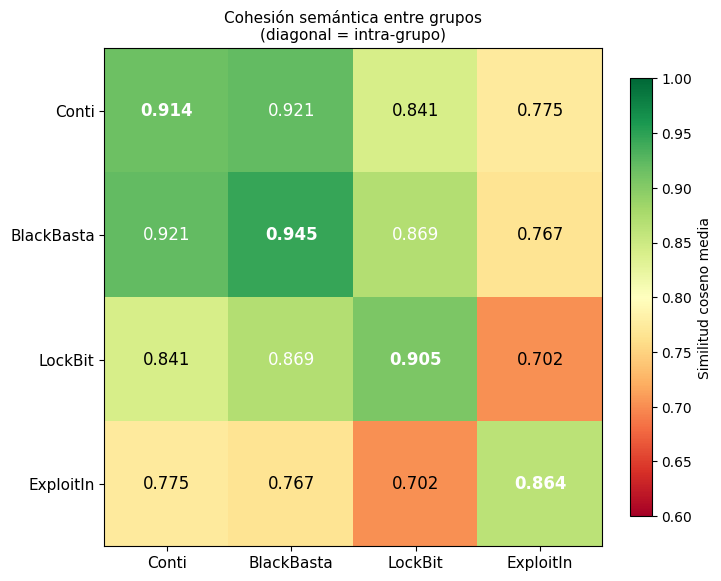

In [3]:
groups = {
    'Conti':     conti_centroids,
    'BlackBasta':bb_centroids,
    'LockBit':   lk_centroids,
    'ExploitIn': ei_centroids,
}
group_names = list(groups.keys())
group_mats  = {g: np.array(list(c.values())) for g, c in groups.items()}

# Matriz 4×4 de similitud media
n = len(group_names)
cohesion = np.zeros((n, n))
for i, gi in enumerate(group_names):
    for j, gj in enumerate(group_names):
        sim = cosine_similarity(group_mats[gi], group_mats[gj])
        if i == j:
            # Intra: excluir diagonal
            idx = np.triu_indices(len(sim), k=1)
            cohesion[i, j] = sim[idx].mean() if len(idx[0]) > 0 else 1.0
        else:
            cohesion[i, j] = sim.mean()

cohesion_df = pd.DataFrame(cohesion, index=group_names, columns=group_names)
print('Matriz de cohesión semántica (similitud coseno media):')
display(cohesion_df.round(3))

# Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cohesion, cmap='RdYlGn', vmin=0.6, vmax=1.0)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(group_names, fontsize=11)
ax.set_yticklabels(group_names, fontsize=11)
ax.set_title('Cohesión semántica entre grupos\n(diagonal = intra-grupo)', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.04, label='Similitud coseno media')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{cohesion[i,j]:.3f}', ha='center', va='center',
                fontsize=12, color='white' if cohesion[i,j] > 0.85 else 'black',
                fontweight='bold' if i == j else 'normal')
plt.tight_layout()
plt.show()

## 3. UMAP conjunto — todos los actores en el mismo espacio

In [4]:
# Para ExploitIn: limitar a top 50 por posts (visual legibilidad)
ei_top50 = ei_msgs.groupby('username').size().nlargest(50).index.tolist()
ei_top50 = [a for a in ei_top50 if a in ei_centroids]

# Construir matriz conjunta
actor_list, vec_list, group_list, role_list = [], [], [], []

for actor, c in conti_centroids.items():
    actor_list.append(actor)
    vec_list.append(c)
    group_list.append('Conti')
    role_list.append(conti_profiles.get(actor, {}).get('role', '?'))

for actor, c in bb_centroids.items():
    actor_list.append(actor)
    vec_list.append(c)
    group_list.append('BlackBasta')
    role_list.append(bb_profiles.get(actor, {}).get('role', '?'))

for actor, c in lk_centroids.items():
    actor_list.append(actor)
    vec_list.append(c)
    group_list.append('LockBit')
    role_list.append(lk_profiles.get(actor, {}).get('role', '?'))

for actor in ei_top50:
    actor_list.append(actor)
    vec_list.append(ei_centroids[actor])
    group_list.append('ExploitIn')
    role_list.append(ei_profiles.get(actor, {}).get('specialty', '?'))

all_vecs = np.array(vec_list)
print(f'Proyectando {len(actor_list)} centroides con UMAP...')
reducer = umap.UMAP(n_neighbors=10, min_dist=0.2, metric='cosine', random_state=42)
coords  = reducer.fit_transform(all_vecs)
print('OK')

Proyectando 147 centroides con UMAP...


/home/drjekyll/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


OK


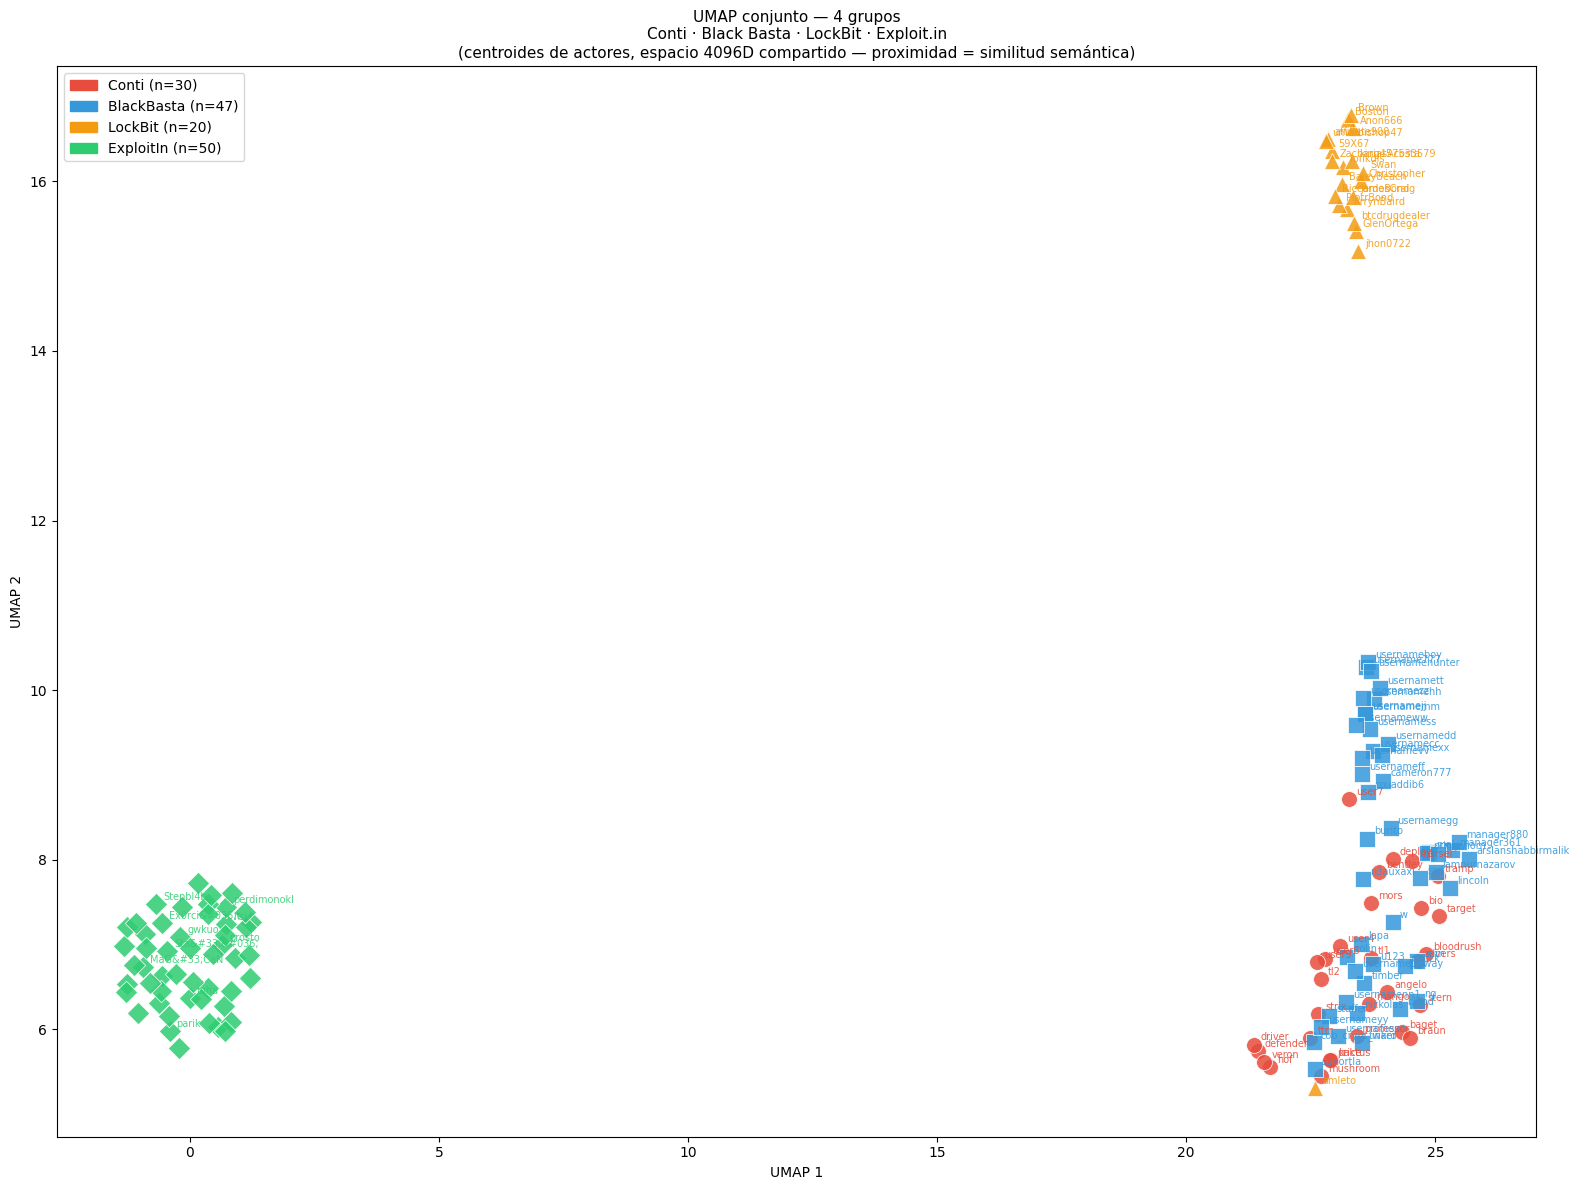

In [5]:
GROUP_COLORS = {
    'Conti':     '#e74c3c',
    'BlackBasta':'#3498db',
    'LockBit':   '#f39c12',
    'ExploitIn': '#2ecc71',
}
GROUP_MARKERS = {'Conti': 'o', 'BlackBasta': 's', 'LockBit': '^', 'ExploitIn': 'D'}

fig, ax = plt.subplots(figsize=(16, 12))

for group in GROUP_COLORS:
    mask = [g == group for g in group_list]
    xs = coords[mask, 0]
    ys = coords[mask, 1]
    ax.scatter(xs, ys, c=GROUP_COLORS[group], marker=GROUP_MARKERS[group],
               s=130, alpha=0.85, edgecolors='white', linewidths=0.6,
               label=f'{group} (n={sum(mask)})', zorder=3)

# Etiquetar todos excepto ExploitIn (demasiados)
for i, (actor, group) in enumerate(zip(actor_list, group_list)):
    if group != 'ExploitIn':
        ax.annotate(actor, (coords[i, 0], coords[i, 1]),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=7, color=GROUP_COLORS[group], alpha=0.9)
    else:
        # Solo etiquetar los 10 más activos de ExploitIn
        top10_ei = ei_msgs.groupby('username').size().nlargest(10).index
        if actor in top10_ei:
            ax.annotate(actor, (coords[i, 0], coords[i, 1]),
                        textcoords='offset points', xytext=(5, 3),
                        fontsize=7, color=GROUP_COLORS[group], alpha=0.85)

legend = [mpatches.Patch(color=GROUP_COLORS[g], label=f'{g} (n={sum(gl==g for gl in group_list)})')
          for g in GROUP_COLORS]
ax.legend(handles=legend, fontsize=10, loc='best')
ax.set_title('UMAP conjunto — 4 grupos\n'
             'Conti · Black Basta · LockBit · Exploit.in\n'
             '(centroides de actores, espacio 4096D compartido — proximidad = similitud semántica)',
             fontsize=11)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

## 4. Heatmap Conti × Black Basta

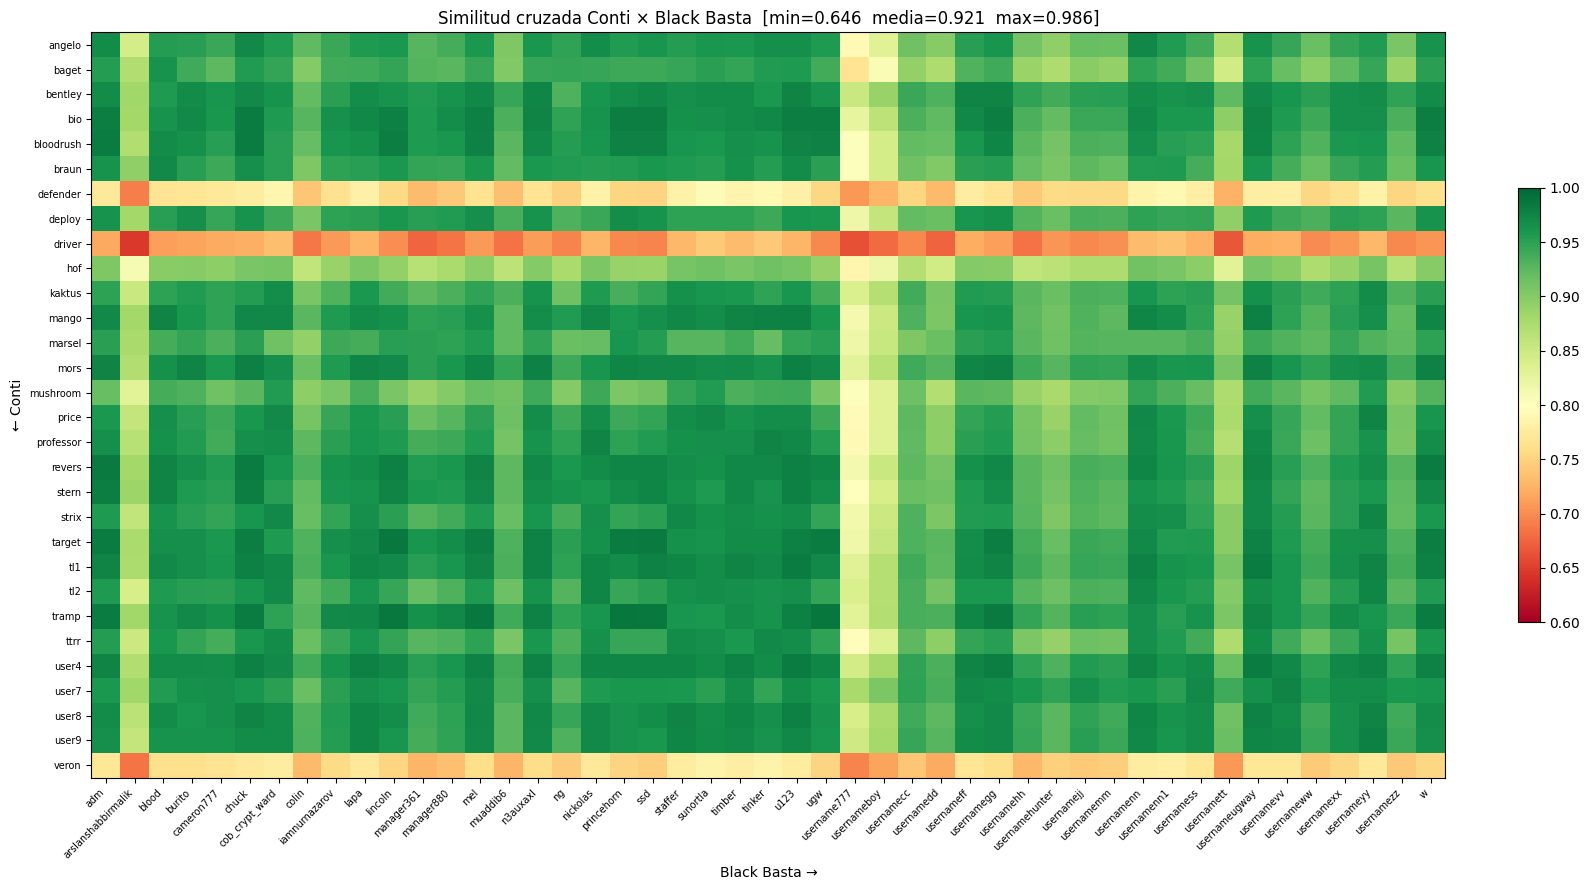

Top 10 pares Conti × BB:
  tramp          [operator  ] ↔ ugw                 [operator  ]  0.986
  tramp          [operator  ] ↔ princehorn          [operator  ]  0.986
  tramp          [operator  ] ↔ lincoln             [operator  ]  0.986
  tramp          [operator  ] ↔ ssd                 [operator  ]  0.985
  tramp          [operator  ] ↔ mel                 [operator  ]  0.985
  target         [operator  ] ↔ lincoln             [operator  ]  0.985
  tramp          [operator  ] ↔ usernamegg          [operator  ]  0.984
  target         [operator  ] ↔ ssd                 [operator  ]  0.983
  revers         [developer ] ↔ adm                 [operator  ]  0.983
  tl1            [operator  ] ↔ u123                [operator  ]  0.983
  tramp          [operator  ] ↔ w                   [developer ]  0.982
  target         [operator  ] ↔ adm                 [operator  ]  0.982
  bloodrush      [operator  ] ↔ adm                 [operator  ]  0.982
  revers         [developer ] ↔ chuck  

In [19]:
conti_actors = sorted(conti_centroids.keys())
bb_actors    = sorted(bb_centroids.keys())
C = np.array([conti_centroids[a] for a in conti_actors])
B = np.array([bb_centroids[a]    for a in bb_actors])
sim_cb = cosine_similarity(C, B)

fig, ax = plt.subplots(figsize=(16, 9))
im = ax.imshow(sim_cb, cmap='RdYlGn', vmin=0.6, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(bb_actors)))
ax.set_xticklabels(bb_actors, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(conti_actors)))
ax.set_yticklabels(conti_actors, fontsize=7)
ax.set_xlabel('Black Basta →', fontsize=10)
ax.set_ylabel('← Conti', fontsize=10)
ax.set_title(f'Similitud cruzada Conti × Black Basta  '
             f'[min={sim_cb.min():.3f}  media={sim_cb.mean():.3f}  max={sim_cb.max():.3f}]')
plt.colorbar(im, ax=ax, fraction=0.015)
plt.tight_layout()
plt.show()

# Top 10 pares
pairs_cb = sorted(
    [(sim_cb[i,j], conti_actors[i], bb_actors[j]) for i in range(len(conti_actors)) for j in range(len(bb_actors))],
    reverse=True
)[:200]
print('Top 10 pares Conti × BB:')
for sim, a, b in pairs_cb:
    ra = conti_profiles.get(a,{}).get('role','?')
    rb = bb_profiles.get(b,{}).get('role','?')
    print(f'  {a:15s}[{ra:10s}] ↔ {b:20s}[{rb:10s}]  {sim:.3f}')

## 5. Exploit.in como fuente — ¿quién de la comunidad del foro comparte estilo con los operadores de ransomware?

Exploit.in (2005–2008) precede a Conti (2020–2022) y a Black Basta (2023–2024).  
Similitud alta entre un usuario del foro y un operador de ransomware puede indicar  
que provienen del mismo ecosistema underground ruso, o que el operador se formó en el foro.

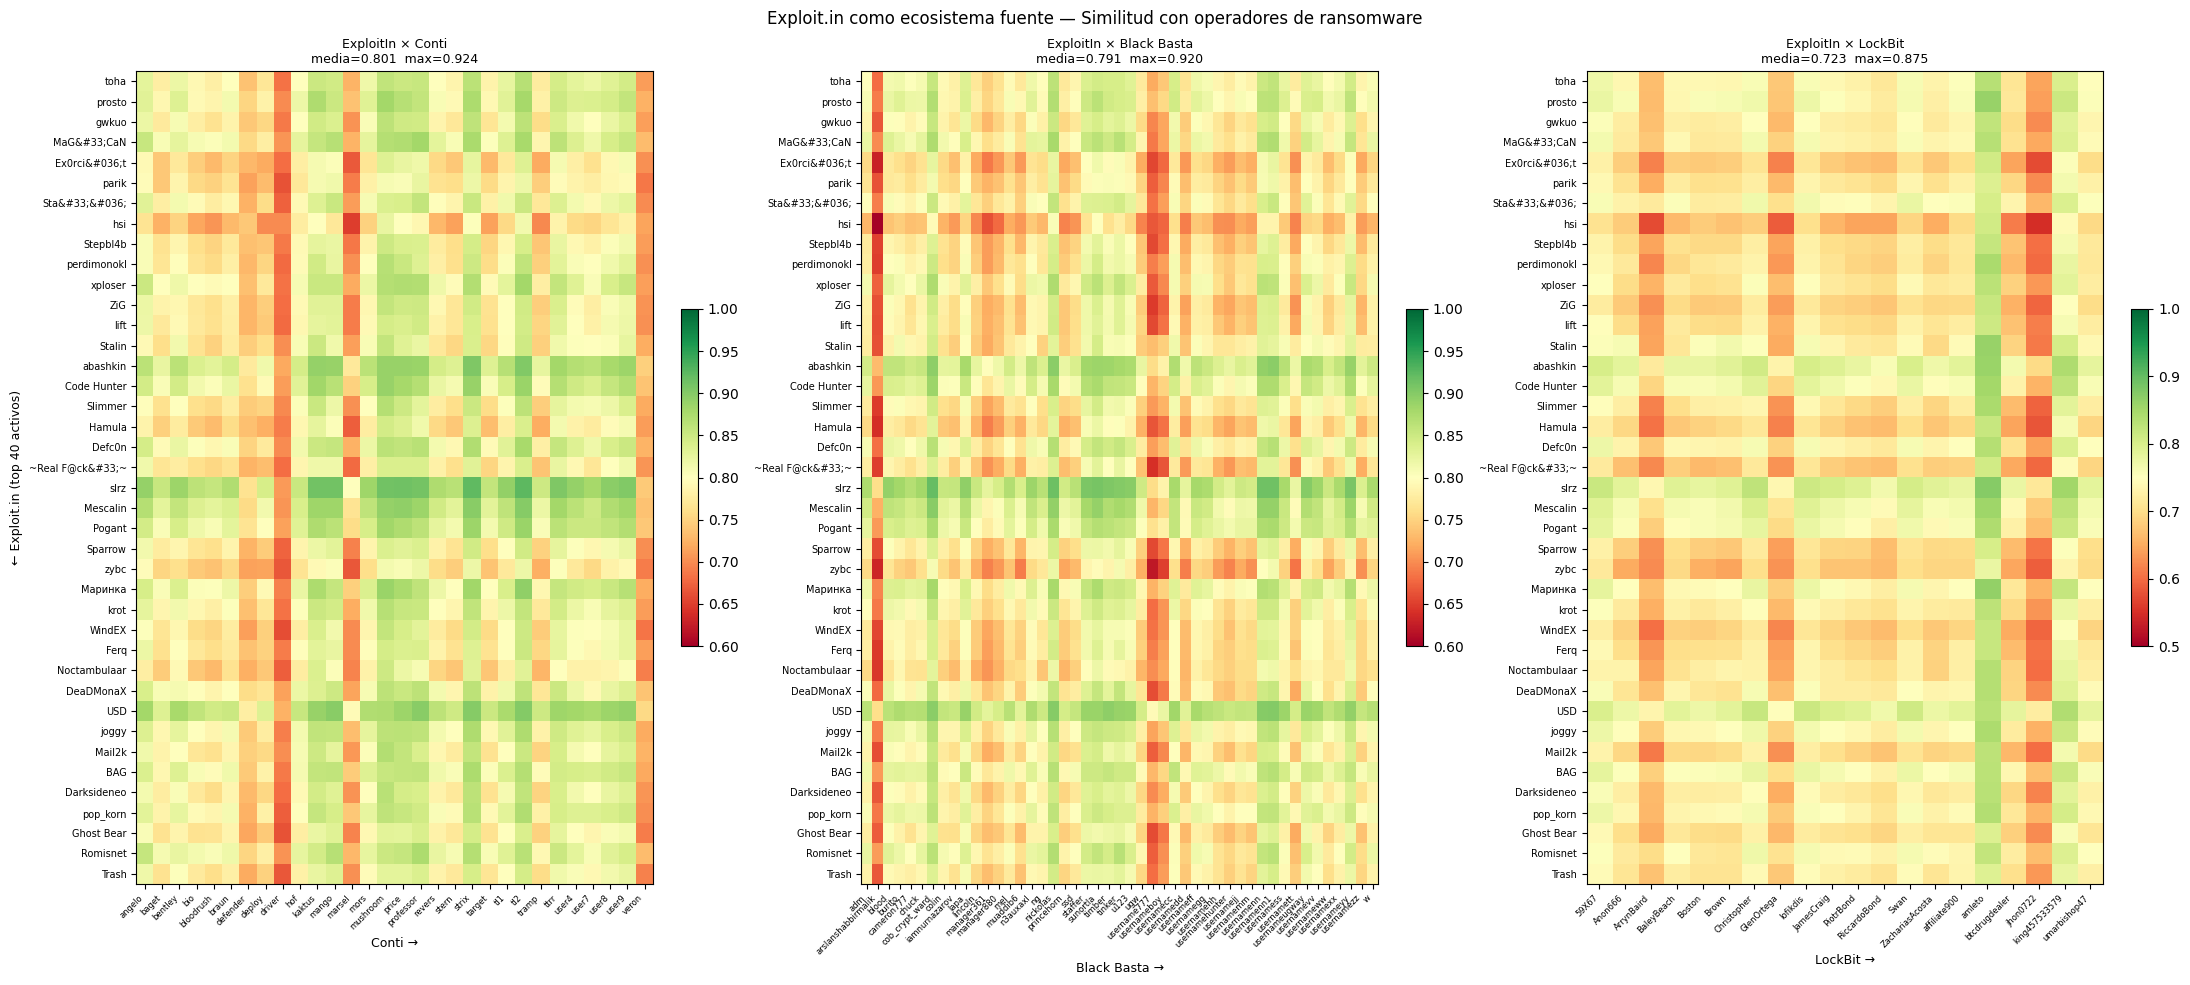

In [7]:
# Top 40 usuarios ExploitIn para heatmaps legibles
ei_top40 = ei_msgs.groupby('username').size().nlargest(40).index.tolist()
ei_top40 = [a for a in ei_top40 if a in ei_centroids]
EI = np.array([ei_centroids[a] for a in ei_top40])

# ExploitIn × Conti
sim_ei_c = cosine_similarity(EI, C)   # (40, 30)
# ExploitIn × BlackBasta
sim_ei_b = cosine_similarity(EI, B)   # (40, 47)
# ExploitIn × LockBit
lk_actors = sorted(lk_centroids.keys())
L = np.array([lk_centroids[a] for a in lk_actors])
sim_ei_l = cosine_similarity(EI, L)   # (40, 20)

# Heatmaps lado a lado
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

for ax, sim, x_labels, x_title, vmin in [
    (axes[0], sim_ei_c, conti_actors, 'Conti', 0.6),
    (axes[1], sim_ei_b, bb_actors,    'Black Basta', 0.6),
    (axes[2], sim_ei_l, lk_actors,    'LockBit', 0.5),
]:
    im = ax.imshow(sim, cmap='RdYlGn', vmin=vmin, vmax=1.0, aspect='auto')
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=6)
    ax.set_yticks(range(len(ei_top40)))
    ax.set_yticklabels(ei_top40, fontsize=7)
    ax.set_xlabel(f'{x_title} →', fontsize=9)
    ax.set_title(f'ExploitIn × {x_title}\nmedia={sim.mean():.3f}  max={sim.max():.3f}', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.03)

axes[0].set_ylabel('← Exploit.in (top 40 activos)', fontsize=9)
plt.suptitle('Exploit.in como ecosistema fuente — Similitud con operadores de ransomware', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# Para cada usuario ExploitIn (top 40), su mejor match en cada grupo ransomware
bridge = []
for i, ei_actor in enumerate(ei_top40):
    best_c_j = sim_ei_c[i].argmax()
    best_b_j = sim_ei_b[i].argmax()
    best_l_j = sim_ei_l[i].argmax()
    bridge.append({
        'ei_user':      ei_actor,
        'ei_specialty': ei_profiles.get(ei_actor, {}).get('specialty', '?'),
        'best_conti':   conti_actors[best_c_j],
        'sim_conti':    round(float(sim_ei_c[i, best_c_j]), 3),
        'best_bb':      bb_actors[best_b_j],
        'sim_bb':       round(float(sim_ei_b[i, best_b_j]), 3),
        'best_lockbit': lk_actors[best_l_j],
        'sim_lockbit':  round(float(sim_ei_l[i, best_l_j]), 3),
    })

bridge_df = pd.DataFrame(bridge)
# Ordenar por máxima similitud con cualquier grupo ransomware
bridge_df['max_sim'] = bridge_df[['sim_conti','sim_bb','sim_lockbit']].max(axis=1)
bridge_df = bridge_df.sort_values('max_sim', ascending=False).reset_index(drop=True)
bridge_df.index += 1

print('=== TOP 20 usuarios de Exploit.in más similares a operadores de ransomware ===')
display(bridge_df.drop(columns='max_sim').head(20))

=== TOP 20 usuarios de Exploit.in más similares a operadores de ransomware ===


,ei_user,ei_specialty,best_conti,sim_conti,best_bb,sim_bb,best_lockbit,sim_lockbit
1,slrz,unknown,tl2,0.924,cob_crypt_ward,0.920,amleto,0.875
2,abashkin,unknown,strix,0.904,nickolas,0.897,amleto,0.858
3,USD,malware,tl2,0.901,usernamenn1,0.901,king457533579,0.839
4,Mescalin,malware,tl2,0.899,cob_crypt_ward,0.898,amleto,0.854
5,Маринка,hacking,tl2,0.893,cob_crypt_ward,0.880,amleto,0.865
6,Code Hunter,malware,mushroom,0.889,cob_crypt_ward,0.885,amleto,0.851
7,Pogant,hacking,tl2,0.887,usernamenn1,0.875,amleto,0.841
8,MaG&#33;CaN,malware,professor,0.881,nickolas,0.877,amleto,0.832
9,prosto,hacking,mushroom,0.880,cob_crypt_ward,0.870,amleto,0.861
10,xploser,hacking,tl2,0.880,nickolas,0.873,amleto,0.830


## 6. Cohesión intra vs inter — distribuciones completas

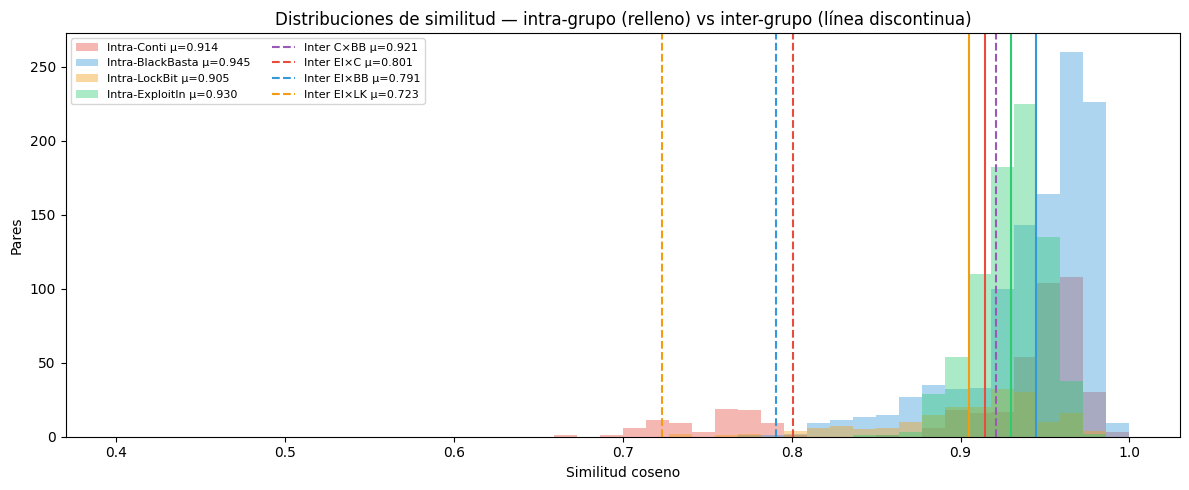

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
bins = np.linspace(0.4, 1.0, 45)

intra_vals = {
    'Conti':      cosine_similarity(C)[np.triu_indices(len(C), k=1)],
    'BlackBasta': cosine_similarity(B)[np.triu_indices(len(B), k=1)],
    'LockBit':    cosine_similarity(L)[np.triu_indices(len(L), k=1)],
    'ExploitIn':  cosine_similarity(EI)[np.triu_indices(len(EI), k=1)],
}
inter_vals = {
    'C×BB':  sim_cb.flatten(),
    'EI×C':  sim_ei_c.flatten(),
    'EI×BB': sim_ei_b.flatten(),
    'EI×LK': sim_ei_l.flatten(),
}

colors_intra = {'Conti':'#e74c3c','BlackBasta':'#3498db','LockBit':'#f39c12','ExploitIn':'#2ecc71'}
colors_inter = {'C×BB':'#9b59b6','EI×C':'#e74c3c','EI×BB':'#3498db','EI×LK':'#f39c12'}

for name, vals in intra_vals.items():
    ax.hist(vals, bins=bins, alpha=0.4, color=colors_intra[name], label=f'Intra-{name} μ={vals.mean():.3f}')
    ax.axvline(vals.mean(), color=colors_intra[name], linestyle='-', lw=1.5)

for name, vals in inter_vals.items():
    ax.axvline(vals.mean(), color=colors_inter[name], linestyle='--', lw=1.5,
               label=f'Inter {name} μ={vals.mean():.3f}')

ax.set_xlabel('Similitud coseno')
ax.set_ylabel('Pares')
ax.set_title('Distribuciones de similitud — intra-grupo (relleno) vs inter-grupo (línea discontinua)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 7. Resumen de hallazgos

In [10]:
print('='*65)
print('COMPARATIVA SEMÁNTICA — 4 GRUPOS')
print('='*65)
print(f'Modelo de embeddings : qwen3-embedding (4096D)')
print(f'Total actores        : {len(actor_list)}')
print()
print('Cohesión intra-grupo (cuánto se parecen entre sí los miembros):')
for g in group_names:
    i = group_names.index(g)
    print(f'  {g:12s}: {cohesion[i,i]:.3f}')
print()
print('Similitud inter-grupo (media):')
for i, gi in enumerate(group_names):
    for j, gj in enumerate(group_names):
        if j > i:
            print(f'  {gi:12s} ↔ {gj:12s}: {cohesion[i,j]:.3f}')
print()
print('Par más similar Conti × BB:')
sim, a, b = pairs_cb[0]
print(f'  {a} ↔ {b}  ({sim:.3f})')
print()
print('Usuario ExploitIn más parecido a ransomware operators:')
top = bridge_df.iloc[0]
print(f'  {top.ei_user} [{top.ei_specialty}]')
print(f'    → mejor Conti   : {top.best_conti} ({top.sim_conti:.3f})')
print(f'    → mejor BB      : {top.best_bb} ({top.sim_bb:.3f})')
print(f'    → mejor LockBit : {top.best_lockbit} ({top.sim_lockbit:.3f})')

COMPARATIVA SEMÁNTICA — 4 GRUPOS
Modelo de embeddings : qwen3-embedding (4096D)
Total actores        : 147

Cohesión intra-grupo (cuánto se parecen entre sí los miembros):
  Conti       : 0.914
  BlackBasta  : 0.945
  LockBit     : 0.905
  ExploitIn   : 0.864

Similitud inter-grupo (media):
  Conti        ↔ BlackBasta  : 0.921
  Conti        ↔ LockBit     : 0.841
  Conti        ↔ ExploitIn   : 0.775
  BlackBasta   ↔ LockBit     : 0.869
  BlackBasta   ↔ ExploitIn   : 0.767
  LockBit      ↔ ExploitIn   : 0.702

Par más similar Conti × BB:
  tramp ↔ ugw  (0.986)

Usuario ExploitIn más parecido a ransomware operators:
  slrz [unknown]
    → mejor Conti   : tl2 (0.924)
    → mejor BB      : cob_crypt_ward (0.920)
    → mejor LockBit : amleto (0.875)
